<a href="https://colab.research.google.com/github/ksheilla/Formative3_machine_learning/blob/main/part%20four/Part%204%3A%20Gradient_Descent_in_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

plt.style.use('ggplot')

In [2]:
class GradientDescent:
    def __init__(self, learning_rate=0.1, iterations=10):
        self.lr = learning_rate
        self.iters = iterations
        self.m = -1.0   # Initial slope
        self.b = 1.0    # Initial intercept
        self.history = {'m': [self.m], 'b': [self.b], 'mse': []}

    def _compute_mse(self, x, y):
        """Compute Mean Squared Error."""
        y_pred = self.m * x + self.b
        return np.mean((y - y_pred) ** 2)

    def _compute_gradients(self, x, y, y_pred):
        """Calculates the partial derivatives for m and b."""
        n = len(x)
        dm = (2 / n) * np.sum(-x * (y - y_pred))
        db = (2 / n) * np.sum(-(y - y_pred))
        return dm, db

    def fit(self, x, y):
        self.history['mse'].append(self._compute_mse(x, y))

        for i in range(self.iters):
            y_pred = self.m * x + self.b
            dm, db = self._compute_gradients(x, y, y_pred)

            # Update parameters
            self.m -= self.lr * dm
            self.b -= self.lr * db

            # Record updated values
            mse = self._compute_mse(x, y)
            self.history['mse'].append(mse)
            self.history['m'].append(self.m)
            self.history['b'].append(self.b)

            print(f"Iteration {i+1}: m={self.m:.4f}, b={self.b:.4f}, MSE={mse:.4f}")

    def predict(self, x):
        """Returns the predicted y values."""
        return self.m * x + self.b

In [3]:
 # Define Dataset we are using

x_train = np.array([1, 3], dtype=float)
y_train = np.array([3, 6], dtype=float)

model = GradientDescent(learning_rate=0.1, iterations=10)
model.fit(x_train, y_train)

final_preds = model.predict(x_train)
print(f"\nFinal Equation (Gradient Descent): y = {model.m:.4f}x + {model.b:.4f}")

Iteration 1: m=1.7000, b=2.1000, MSE=1.0400
Iteration 2: m=1.2600, b=1.9000, MSE=0.0640
Iteration 3: m=1.3400, b=1.9160, MSE=0.0348
Iteration 4: m=1.3336, b=1.8968, MSE=0.0318
Iteration 5: m=1.3413, b=1.8840, MSE=0.0296
Iteration 6: m=1.3464, b=1.8707, MSE=0.0276
Iteration 7: m=1.3517, b=1.8580, MSE=0.0258
Iteration 8: m=1.3568, b=1.8457, MSE=0.0240
Iteration 9: m=1.3617, b=1.8338, MSE=0.0224
Iteration 10: m=1.3665, b=1.8224, MSE=0.0209

Final Equation (Gradient Descent): y = 1.3665x + 1.8224


In [5]:
def mse_cost(params, x, y):
    """MSE cost function for SciPy optimizer."""
    m, b = params
    y_pred = m * x + b
    return np.mean((y - y_pred) ** 2)

initial_params = np.array([-1.0, 1.0])

result = minimize(
    mse_cost,
    initial_params,
    args=(x_train, y_train),
    method='BFGS'
)

scipy_m, scipy_b = result.x
print(f"\nFinal m (SciPy minimize): {scipy_m:.4f}")
print(f"Final b (SciPy minimize): {scipy_b:.4f}")


Final m (SciPy minimize): 1.5000
Final b (SciPy minimize): 1.5000


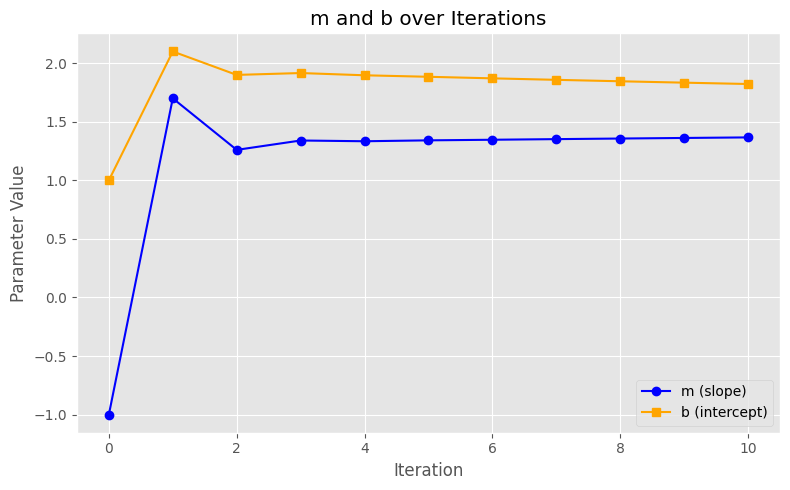

In [9]:

# 4. Plot 1 — m and b values over iterations
iterations_range = range(len(model.history['m']))

fig1, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(iterations_range, model.history['m'], label='m (slope)', marker='o', color='blue')
ax1.plot(iterations_range, model.history['b'], label='b (intercept)', marker='s', color='orange')
ax1.set_title("m and b over Iterations")
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Parameter Value")
ax1.legend()
plt.tight_layout()
plt.show()

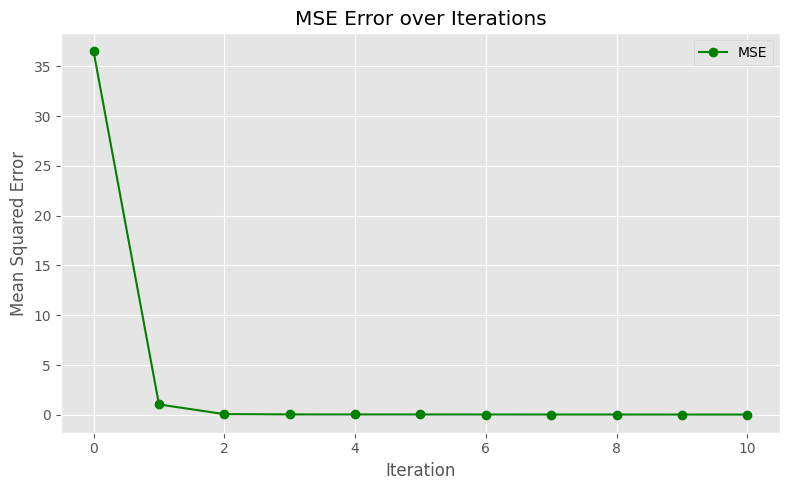

In [8]:
# 5. Plot 2 — MSE Error over iterations
fig2, ax2 = plt.subplots(figsize=(8, 5))
ax2.plot(model.history['mse'], color='green', marker='o', label='MSE')
ax2.set_title("MSE Error over Iterations")
ax2.set_xlabel("Iteration")
ax2.set_ylabel("Mean Squared Error")
ax2.legend()
plt.tight_layout()
plt.show()